## GSMAP
A hands-on

Prepared by: **Alpon Sepriando**

Public Weather Services, BMKG — Indonesia

📧 *alpon.sepriando@bmkg.go.id*

🔗 https://github.com/sepriando/

In [1]:
!pip install basemap

In [2]:
from datetime import datetime,timedelta
import os
import ftplib
import gzip
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import imageio.v2 as imageio

In [3]:
#####Change these values ###############
startime = datetime(2023,2,6,0)
endtime = datetime(2023,2,6,5)
latP,lonP = -8.743,115.162 #point of target
lat1,lat2,lon1,lon2 = -7.5,-9.5, 114,116 #border of map
########################################

In [4]:
#function to create folder
def create_folder(date,folder):
    path = folder + date.strftime("/%Y/%m/%d")
    if not os.path.exists(path):
        os.makedirs(path)
    return path

In [5]:
# function to download a file from an FTP server
def download_ftp_file(file_name, ftp_dir, local_dir):
    ftp = ftplib.FTP("hokusai.eorc.jaxa.jp") # connect to the FTP server
    ftp.login("rainmap", "Niskur+1404") # login to the FTP server with the provided username and password
    ftp.cwd(ftp_dir) # navigate to the desired directory on the FTP server
    local_file = local_dir+'/'+ file_name
    ftp_file =ftp_dir+'/'+file_name
    ftp_size= ftp.sendcmd("TYPE i")
    ftp_size = ftp.size(ftp_file)
    if os.path.exists(local_file):
        if os.path.getsize(local_file) == ftp_size:
            print(file_name + " already exists and skipped")
    else:
      with open(local_file, "wb") as f:
          ftp.retrbinary("RETR " + file_name, f.write)
      print(file_name + " downloaded")
    ftp.quit() # close the FTP connection

In [6]:
#function to extract gz files
def extract_gz_files(local_file):
    with gzip.open(local_file, "rb") as f_in:
        # extract the name of the file without the .gz extension
        extracted_file = local_file[:-3]
        with open(extracted_file, "wb") as f_out:
            f_out.write(f_in.read())
    return extracted_file

In [7]:
#function to read GSMaP file
def readGSMaP(filegsmap):
    data = np.fromfile(filegsmap,dtype='f4')
    data = np.reshape(data,(1200,3600))
    lon = np.arange(0.05, 0.05+3600*0.1, 0.1)
    lat = np.arange(-59.95, -59.95+1200*0.1, 0.1)
    return lon,lat,data

In [8]:
#function to generate a image
def mapping(lon,lat,data,date):
    folder = create_folder(initime,'image')
    fig, ax = plt.subplots()
    ulat,dlat,llon,rlon = lat1,lat2,lon1,lon2
    Map = Basemap(resolution='i',llcrnrlon=llon, llcrnrlat=dlat, urcrnrlon=rlon,urcrnrlat=ulat)
    Map.drawparallels(np.arange(-60,60,1.),labels=[1,0,0,0],fontsize=4,linewidth=0.3,color='#999999')
    Map.drawmeridians(np.arange(-180,180,1.),labels=[0,0,0,1],fontsize=4,linewidth=0.3,color='#999999')
    Map.fillcontinents(color='#FFE2AB')
    Map.drawcoastlines(linewidth=0.5,color='#333333',zorder=11)

    x,y = np.meshgrid(lons,lats)
    lev = [0.1,5,10,20,1000]
    tick = [str(i) for i in lev]
    data = np.flipud(data)
    col = ['#7FFFFF','#55FF55','#FFFF55','#FF2A55']
    cax = Map.contourf(x,y,data,levels=lev,colors=col)
    cb = plt.colorbar(cax,ticks=lev,pad=0.01,orientation='vertical',shrink=0.75)
    cb.ax.set_yticklabels(tick,fontsize=4.)
    cb.ax.set_title('mm/hr',fontsize=4.)

    x,y = Map(llon,ulat+(ulat-dlat)/25)
    plt.text(x,y,'GSMaP Hourly Precipitation',fontsize=6,weight='bold')
    x,y = Map(rlon,ulat+(ulat-dlat)/25)
    plt.text(x,y,date.strftime('Time %H UTC : %d-%m-%Y'),fontsize=6,horizontalalignment='right')
    x,y = Map(llon,ulat+(ulat-dlat)/75)
    plt.text(x,y,'Training Output by BMKG, '+date.strftime('%Y'),fontsize=4,color='gray')
    x,y = Map(rlon,ulat+(ulat-dlat)/75)
    plt.text(x,y,r'Data Source by JAXA',fontsize=4,color='gray',horizontalalignment='right')
    Map.scatter(lonP, latP, marker='o', color = 'blue', alpha=0.6)

    fimage = folder+date.strftime('/GSMaP_Hourly_%Y%m%d%H00.png')
    fig.savefig(fimage,dpi=250,bbox_inches='tight',pad_inches=0.1)
    plt.show()
    plt.close()
    return fimage

In [9]:
#get value base on point
def getValue(data,lat,lon):
    lat = (60-lat)*10
    lon = lon*10
    value = round(data[int(lat),int(lon)],1)
    return value

In [10]:
def saveValue(datev,timev,rainrate):
  f = open('rainrate.txt','w')
  f.write('date\ttime(UTC)\tlongitude\tlatitude\trainrate(mm/hr))\n')
  for i,j,k in zip(datev,timev,rainrate):
      f.write(('%s\t%s\t%.3f\t%.3f\t%.1f\n')%(i,j,lonP,latP,k))
  f.close()

In [11]:
def plot_graph(datev,timev,rainrate):
  dttm = [i+': '+j for i,j in zip(datev,timev)]

  fig, ax = plt.subplots()
  ax.bar(dttm,rainrate)

  # Add the values to the top of each bar
  for i, v in enumerate(rainrate):
      ax.text(i, v+v/100, str(v), ha='center', fontweight='bold')

  plt.title('GSMaP Rainrate\n lon: '+str(lonP)+', lat: '+str(latP))
  plt.subplots_adjust(top=0.85, right=0.85)
  plt.ylabel('rainrate(mm/hr)')
  plt.ylim(0,)
  plt.xlabel('Time(UTC)')
  plt.xticks(rotation=30, ha='right')
  plt.savefig('graph.png',dpi=150)
  plt.show()

gsmap_nrt.20230206.0000.dat.gz downloaded


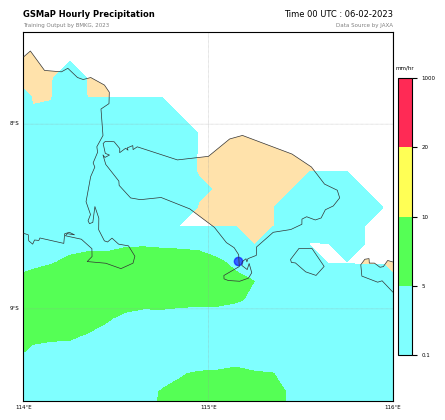

gsmap_nrt.20230206.0100.dat.gz downloaded


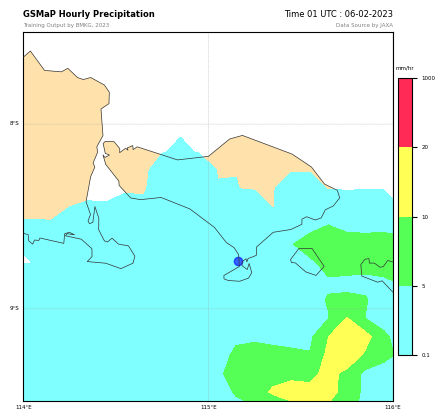

gsmap_nrt.20230206.0200.dat.gz downloaded


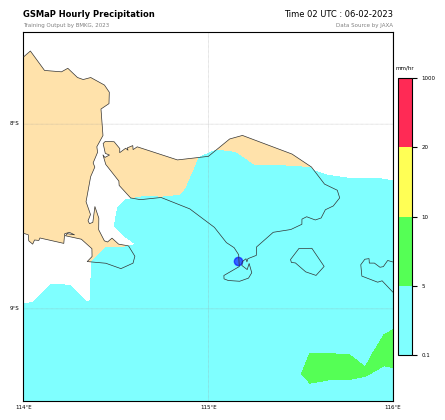

gsmap_nrt.20230206.0300.dat.gz downloaded


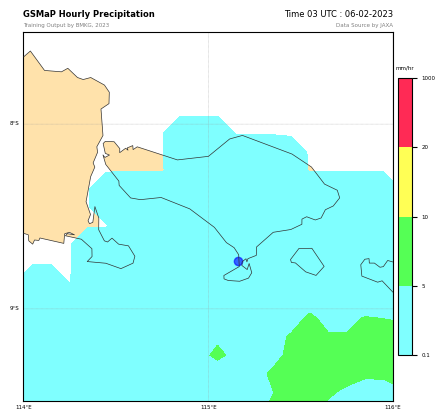

gsmap_nrt.20230206.0400.dat.gz downloaded


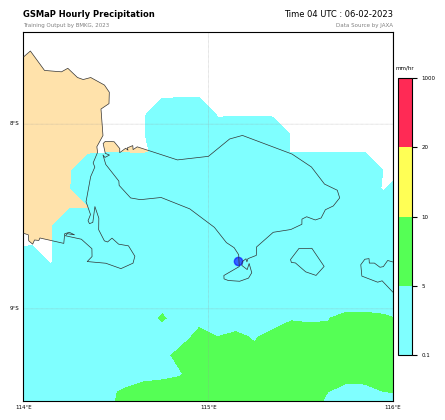

gsmap_nrt.20230206.0500.dat.gz downloaded


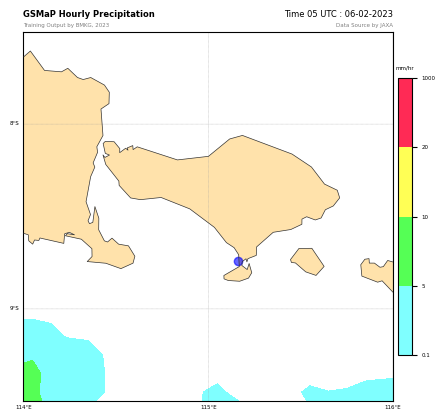

In [12]:
images,rainrate,datev,timev = [],[],[],[]

startime = datetime(2023,2,6,0)
endtime = datetime(2023,2,6,5)

initime = startime
while initime <= endtime:
    #print(initime)
    file_name = initime.strftime('gsmap_nrt.%Y%m%d.%H%M.dat.gz')
    local_dir = create_folder(initime,'data')
    local_file = os.path.join(local_dir, file_name)
    ftp_dir = "/realtime_ver/v6/archive/" + initime.strftime("%Y/%m/%d")

    download_ftp_file(file_name, ftp_dir, local_dir)
    extracted_file = extract_gz_files(local_file)
    lons,lats,data = readGSMaP(extracted_file)
    #os.remove(extracted_file)
    fimage = mapping(lons,lats,data,initime)
    images.append(imageio.imread(fimage))

    value = getValue(data,latP,lonP)
    rainrate.append(value)
    timev.append(initime.strftime('%H Z'))
    datev.append(initime.strftime('%Y-%m-%d'))

    initime = initime+timedelta(hours=1)

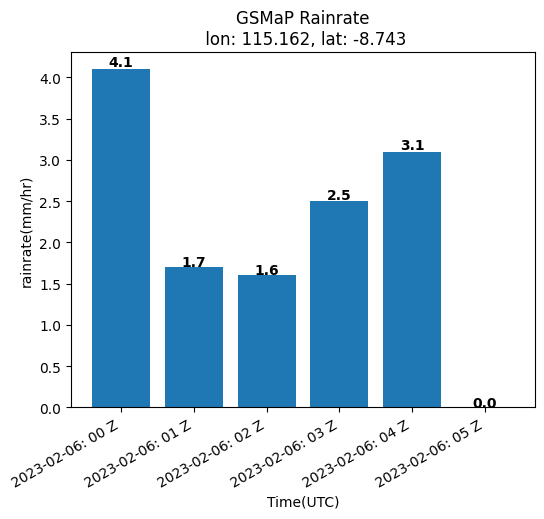

In [13]:
#Save value of rainrate
saveValue(datev,timev,rainrate)

#plot time series graph
plot_graph(datev,timev,rainrate)

#generate an animation
imageio.mimsave('animation.gif', images, fps=1,loop=0)

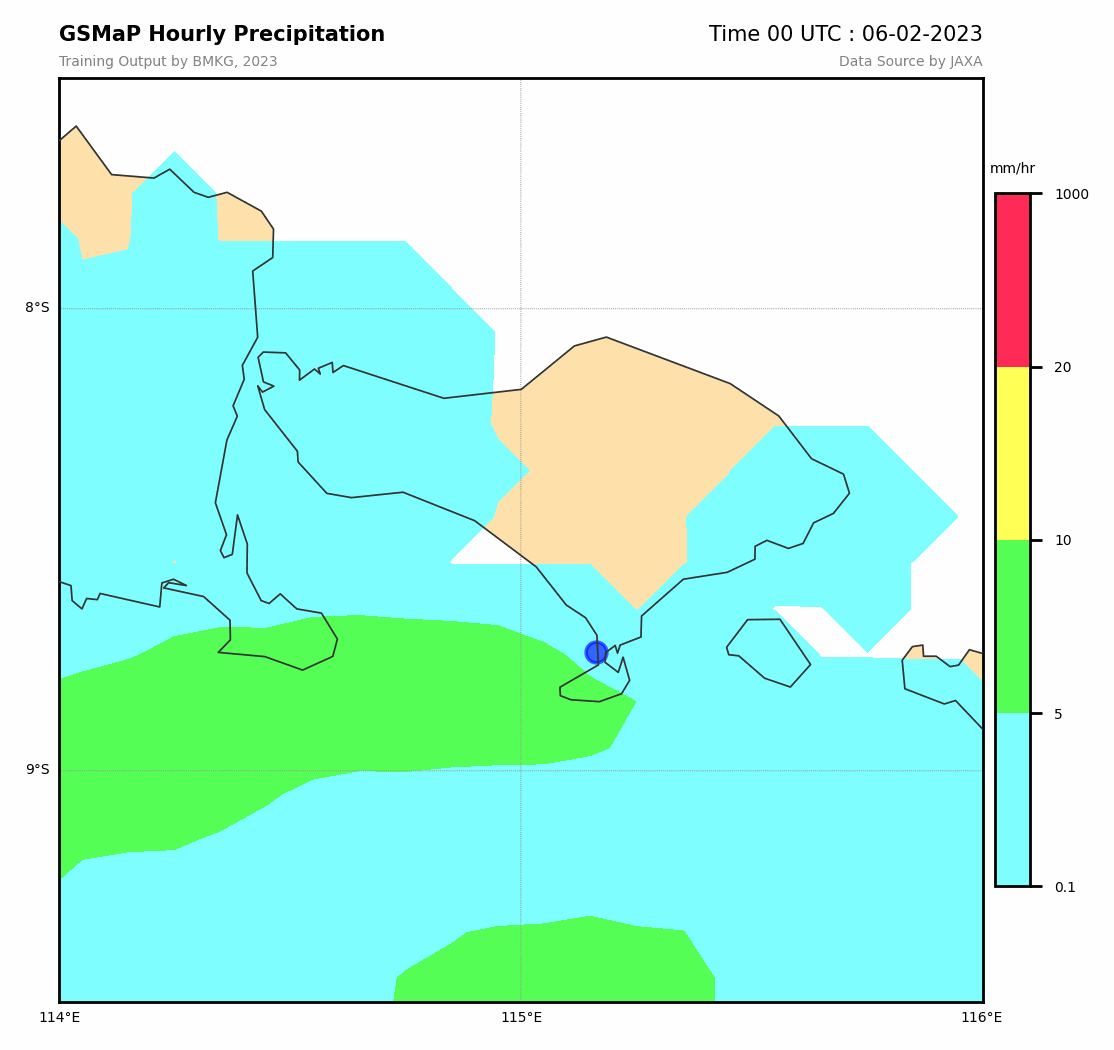

In [14]:
#Show an animation
from IPython.display import Image
Image('animation.gif')